# I-JEPA Region Embedding Extraction - Debug Notebook

This notebook runs the region embedding extraction script **directly** (no SLURM) for debugging and testing.

## What it does:
1. Extracts ViT patch tokens (I-JEPA/DINOv2/DINO)
2. Pools them per SAM mask (REN-style einsum)
3. Projects to 256-dim
4. Saves as .npz files

## For production runs:
Use `sbatch scripts/submit_region_extraction.sh` instead.

## Configuration

Set your backbone and paths below:

In [2]:
import sys
import os
import importlib
from pathlib import Path

# ──────────── Paths ────────────
REPO_ROOT = "/scratch/gilbreth/abelde/Thesis/StructureAwareGen"
SCRIPT_DIR = f"{REPO_ROOT}/scripts/segProto"

# Add script directory to path
if SCRIPT_DIR not in sys.path:
    sys.path.insert(0, SCRIPT_DIR)

# Import the extraction script
import precompute_region_embeddings
importlib.reload(precompute_region_embeddings)

# ──────────── Configuration ────────────
# Choose backbone: ijepa_vit_h14 | dinov2_vitl14 | dino_vitb8
BACKBONE = "ijepa_vit_h14"

# Paths
IMAGE_DIR = f"{REPO_ROOT}/dataset/imagenet-1K-hf/train"
SAM_CHECKPOINT = f"{SCRIPT_DIR}/checkpoints/sam_vit_b_01ec64.pth"
IJEPA_CHECKPOINT = f"{REPO_ROOT}/scripts/SEG-RDM/rdm/pretrained_enc_ckpts/ijepa/IN1K-vit.h.14-300e.pth.tar"

# Output directory (based on backbone)
OUTPUT_DIRS = {
    "ijepa_vit_h14": f"{REPO_ROOT}/sam_cache_ijepa_debug",
    "dinov2_vitl14": f"{REPO_ROOT}/sam_cache_dinov2_debug",
    "dino_vitb8": f"{REPO_ROOT}/sam_cache_dino_debug",
}
OUTPUT_DIR = OUTPUT_DIRS[BACKBONE]

# ──────────── Debugging params ────────────
SUBSET_FRACTION = 0.001  # Extract only 0.1% for testing (5-10 images per class)
MAX_IMAGES = 50          # Hard limit for debugging
SKIP_EXISTING = True

# SAM AMG parameters
POINTS_PER_SIDE = 32
PRED_IOU_THRESH = 0.82
STABILITY_THRESH = 0.85
MAX_KEEP = 100
DEDUP_IOU_THRESH = 0.50

# Embedding options
MEAN_SUBTRACT = False    # Default: False (test raw I-JEPA features first)

print(f"✓ Backbone: {BACKBONE}")
print(f"✓ Output: {OUTPUT_DIR}")
print(f"✓ Subset: {SUBSET_FRACTION*100:.1f}% (~{MAX_IMAGES} images max)")
print(f"✓ Mean subtraction: {MEAN_SUBTRACT}")

✓ Backbone: ijepa_vit_h14
✓ Output: /scratch/gilbreth/abelde/Thesis/StructureAwareGen/sam_cache_ijepa_debug
✓ Subset: 0.1% (~50 images max)
✓ Mean subtraction: False


## Run Extraction (Direct - No SLURM)

This cell runs the extraction script directly with command-line arguments:

In [2]:
# ──────────── Build CLI args ────────────
sys.argv = [
    "precompute_region_embeddings.py",
    "--image_dir", IMAGE_DIR,
    "--output_dir", OUTPUT_DIR,
    "--sam_checkpoint", SAM_CHECKPOINT,
    "--sam_model_type", "vit_b",
    
    # Backbone selection
    "--backbone", BACKBONE,
]

# Add backbone-specific checkpoint
if BACKBONE == "ijepa_vit_h14":
    sys.argv += ["--ijepa_checkpoint", IJEPA_CHECKPOINT]

# SAM AMG parameters
sys.argv += [
    "--points_per_side", str(POINTS_PER_SIDE),
    "--pred_iou_thresh", str(PRED_IOU_THRESH),
    "--stability_score_thresh", str(STABILITY_THRESH),
    "--crop_n_layers", "0",
]

# Post-processing
sys.argv += [
    "--max_keep", str(MAX_KEEP),
    "--dedup_iou_thresh", str(DEDUP_IOU_THRESH),
]

# Embedding options
if MEAN_SUBTRACT:
    sys.argv += ["--mean_subtract"]

# Runtime options
sys.argv += [
    "--subset_fraction", str(SUBSET_FRACTION),
    "--max_images", str(MAX_IMAGES),
    "--seed", "42",
]

if SKIP_EXISTING:
    sys.argv += ["--skip_existing"]

print("Command line args:")
print(" ".join(sys.argv))
print("\n" + "="*80)

# ──────────── Run extraction ────────────
try:
    precompute_region_embeddings.main()
    print("\n✅ Extraction completed successfully!")
except KeyboardInterrupt:
    print("\n⚠️  Interrupted by user")
except Exception as e:
    print(f"\n❌ Error: {e}")
    import traceback
    traceback.print_exc()

Command line args:
precompute_region_embeddings.py --image_dir /scratch/gilbreth/abelde/Thesis/StructureAwareGen/dataset/imagenet-1K-hf/train --output_dir /scratch/gilbreth/abelde/Thesis/StructureAwareGen/sam_cache_ijepa_debug --sam_checkpoint /scratch/gilbreth/abelde/Thesis/StructureAwareGen/scripts/segProto/checkpoints/sam_vit_b_01ec64.pth --sam_model_type vit_b --backbone ijepa_vit_h14 --ijepa_checkpoint /scratch/gilbreth/abelde/Thesis/StructureAwareGen/scripts/SEG-RDM/rdm/pretrained_enc_ckpts/ijepa/IN1K-vit.h.14-300e.pth.tar --points_per_side 32 --pred_iou_thresh 0.82 --stability_score_thresh 0.85 --crop_n_layers 0 --max_keep 100 --dedup_iou_thresh 0.5 --subset_fraction 0.001 --max_images 50 --seed 42 --skip_existing

[Single GPU mode] Using device cuda
Using 1 GPUs for parallel processing
Backbone: ijepa_vit_h14
IoU dedup threshold: 0.5
Mean subtraction: False
Loading SAM model (vit_b)...


/home/abelde/.local/lib/python3.9/site-packages/networkx/utils/backends.py:135: RuntimeWarning: networkx backend defined more than once: nx-loopback
  backends.update(_get_backends("networkx.backends"))


Loading backbone: ijepa_vit_h14...
[env] module=rdm
[env] python=3.9.23 | packaged by conda-forge | (main, Jun  4 2025, 17:57:12)  [GCC 13.3.0]
[env] module=rdm.pretrained_enc.ijepa
[env] python=3.9.23 | packaged by conda-forge | (main, Jun  4 2025, 17:57:12)  [GCC 13.3.0]
[env] module=rdm.pretrained_enc.moco_v3
[env] python=3.9.23 | packaged by conda-forge | (main, Jun  4 2025, 17:57:12)  [GCC 13.3.0]
[env] module=rdm.pretrained_enc.moco_v3.vits
[env] python=3.9.23 | packaged by conda-forge | (main, Jun  4 2025, 17:57:12)  [GCC 13.3.0]
[env] torch=2.7.0+cu126
[env] torch.cuda=12.6
[env] cudnn=90501


/home/abelde/.local/lib/python3.9/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


[env] module=rdm.pretrained_enc.dino
[env] python=3.9.23 | packaged by conda-forge | (main, Jun  4 2025, 17:57:12)  [GCC 13.3.0]
[env] module=rdm.pretrained_enc.dino.vits
[env] python=3.9.23 | packaged by conda-forge | (main, Jun  4 2025, 17:57:12)  [GCC 13.3.0]
[env] torch=2.7.0+cu126
[env] torch.cuda=12.6
[env] cudnn=90501
[env] module=rdm.pretrained_enc.ibot
[env] python=3.9.23 | packaged by conda-forge | (main, Jun  4 2025, 17:57:12)  [GCC 13.3.0]
[env] module=rdm.pretrained_enc.ibot.vits
[env] python=3.9.23 | packaged by conda-forge | (main, Jun  4 2025, 17:57:12)  [GCC 13.3.0]
[env] torch=2.7.0+cu126
[env] torch.cuda=12.6
[env] cudnn=90501
[env] module=rdm.pretrained_enc.deit
[env] python=3.9.23 | packaged by conda-forge | (main, Jun  4 2025, 17:57:12)  [GCC 13.3.0]
[env] module=rdm.pretrained_enc.deit.vits
[env] python=3.9.23 | packaged by conda-forge | (main, Jun  4 2025, 17:57:12)  [GCC 13.3.0]
[env] torch=2.7.0+cu126
[env] torch.cuda=12.6
[env] cudnn=90501


/home/abelde/.local/lib/python3.9/site-packages/timm/models/registry.py:4: FutureWarning: Importing from timm.models.registry is deprecated, please import via timm.models
  warnings.warn(f"Importing from {__name__} is deprecated, please import via timm.models", FutureWarning)
/scratch/gilbreth/abelde/Thesis/StructureAwareGen/scripts/SEG-RDM/rdm/pretrained_enc/deit/vits.py:70: UserWarning: Overwriting deit_tiny_patch16_224 in registry with rdm.pretrained_enc.deit.vits.deit_tiny_patch16_224. This is because the name being registered conflicts with an existing name. Please check if this is not expected.
  def deit_tiny_patch16_224(pretrained=False, **kwargs):
/scratch/gilbreth/abelde/Thesis/StructureAwareGen/scripts/SEG-RDM/rdm/pretrained_enc/deit/vits.py:85: UserWarning: Overwriting deit_small_patch16_224 in registry with rdm.pretrained_enc.deit.vits.deit_small_patch16_224. This is because the name being registered conflicts with an existing name. Please check if this is not expected.
  

: 

## Inspect Single Extracted File

Load and examine one .npz file to verify the structure:

In [2]:
import numpy as np
import glob

# Find first extracted npz file
npz_pattern = f"{OUTPUT_DIR}/*/masks_npz/*.npz"
npz_files = glob.glob(npz_pattern)

if len(npz_files) == 0:
    print("⚠️  No .npz files found yet. Run extraction first.")
else:
    npz_path = npz_files[0]
    print(f"Inspecting: {npz_path}")
    print(f"File size: {os.path.getsize(npz_path) / 1024:.1f} KB\n")
    
    data = np.load(npz_path)
    
    print("Keys:", list(data.keys()))
    print("\nContents:")
    for key in data.keys():
        val = data[key]
        if isinstance(val, np.ndarray):
            shape_str = str(val.shape)
            print(f"  {key:20s} shape={shape_str:20s} dtype={val.dtype}")
            if val.dtype in [np.float32, np.float64] and val.size > 0:
                print(f"                       min={val.min():.3f}, max={val.max():.3f}, mean={val.mean():.3f}")
        else:
            print(f"  {key:20s} type={type(val).__name__}")
    
    # Check for mean subtraction
    if 'emb_image_mean' in data:
        print(f"\n✓ Mean subtraction enabled (emb_image_mean present)")
    else:
        print(f"\n✓ Mean subtraction disabled (raw features)")
    
    data.close()

Inspecting: /scratch/gilbreth/abelde/Thesis/StructureAwareGen/sam_cache_ijepa_debug/0/masks_npz/27954.npz
File size: 16.8 KB

Keys: ['packed', 'shape', 'scores', 'label_map', 'emb']

Contents:
  packed               shape=(12, 6313)           dtype=uint8
  shape                shape=(3,)                 dtype=int32
  scores               shape=(12,)                dtype=float32
                       min=0.757, max=0.983, mean=0.873
  label_map            shape=(202, 250)           dtype=int32
  emb                  shape=(12, 256)            dtype=float32
                       min=-3.111, max=2.965, mean=-0.013

✓ Mean subtraction disabled (raw features)


## View Metadata JSON

Inspect the metadata for extracted masks:

In [3]:
import json

# Find first metadata JSON
json_pattern = f"{OUTPUT_DIR}/*/meta/*.json"
json_files = glob.glob(json_pattern)

if len(json_files) == 0:
    print("⚠️  No metadata JSON files found yet.")
else:
    json_path = json_files[0]
    print(f"Reading: {json_path}\n")
    
    with open(json_path, 'r') as f:
        metadata = json.load(f)
    
    # Print summary
    print(f"Image: {Path(metadata['image']).name}")
    print(f"Backbone: {metadata['backbone']}")
    print(f"Embed dim: {metadata['embed_dim']} → Proj dim: {metadata['proj_dim']}")
    print(f"Num masks: {metadata['num_masks']}")
    print(f"Mean subtracted: {metadata['mean_subtracted']}")
    print(f"Dedup IoU threshold: {metadata['dedup_iou_thresh']}")
    
    # Show first 3 masks
    if 'masks' in metadata and len(metadata['masks']) > 0:
        print(f"\nFirst 3 masks:")
        for i, mask in enumerate(metadata['masks'][:3]):
            print(f"  Mask {i}:")
            print(f"    Score: {mask['score']:.3f} (IoU: {mask['predicted_iou']:.3f}, Stab: {mask['stability_score']:.3f})")
            print(f"    Area: {mask['area_px']} px ({mask['area_frac']*100:.2f}%)")
            print(f"    BBox: {mask['bbox_xywh']}")
            print(f"    Center: ({mask['cx']:.2f}, {mask['cy']:.2f})")

Reading: /scratch/gilbreth/abelde/Thesis/StructureAwareGen/sam_cache_ijepa_debug/0/meta/27954.json

Image: 27954.JPEG
Backbone: ijepa_vit_h14
Embed dim: 1280 → Proj dim: 256
Num masks: 12
Mean subtracted: False
Dedup IoU threshold: 0.5

First 3 masks:
  Mask 0:
    Score: 0.983 (IoU: 1.002, Stab: 0.981)
    Area: 4582 px (9.07%)
    BBox: [161, 62, 89, 70]
    Center: (0.84, 0.49)
  Mask 1:
    Score: 0.932 (IoU: 0.965, Stab: 0.966)
    Area: 2915 px (5.77%)
    BBox: [83, 0, 97, 60]
    Center: (0.52, 0.11)
  Mask 2:
    Score: 0.914 (IoU: 0.948, Stab: 0.964)
    Area: 410 px (0.81%)
    BBox: [218, 0, 26, 24]
    Center: (0.92, 0.05)


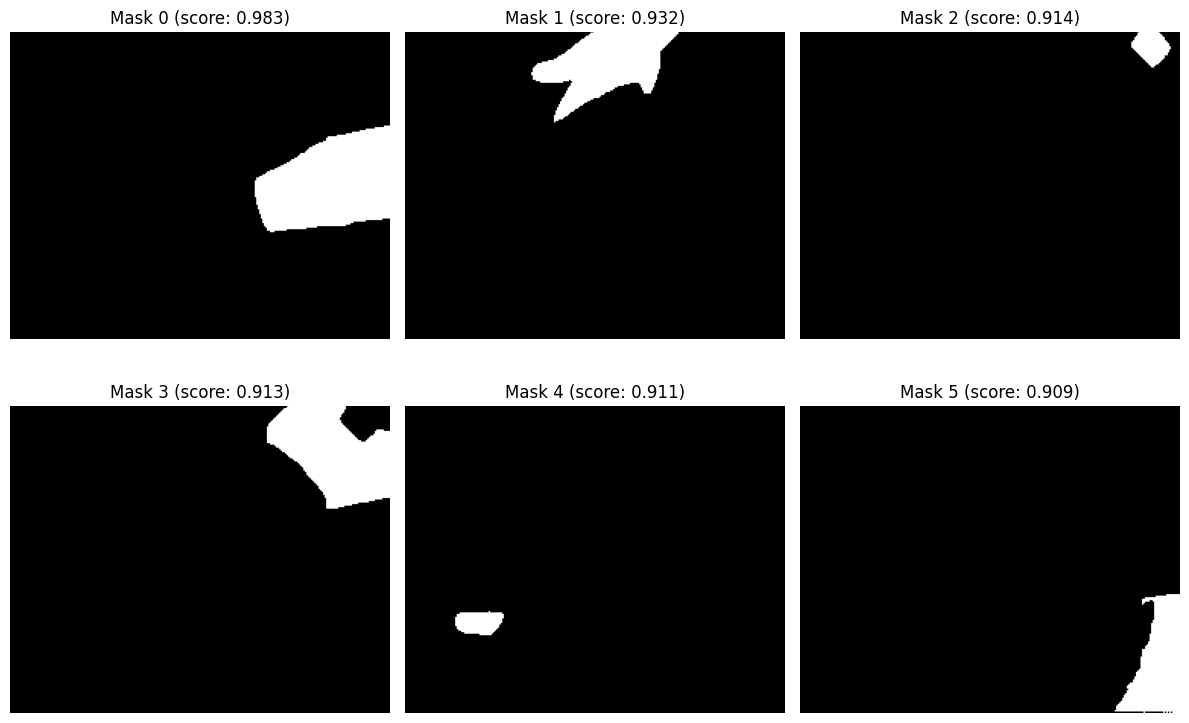

Visualized 6 masks from 27954.npz


In [12]:
import matplotlib.pyplot as plt
import matplotlib.patches as patches

# Visualize masks from the first extracted file
if len(npz_files) > 0:
    npz_path = npz_files[0]
    data = np.load(npz_path)
    
    # Unpack masks
    packed = data['packed']
    shape = tuple(data['shape'])
    scores = data['scores']
    
    if shape[0] > 0:
        # Unpack binary masks (slice to H*W before reshaping)
        N, H, W = shape
        masks = np.unpackbits(packed, axis=1)[:, :H*W].reshape(N, H, W).astype(bool)
        
        # Plot first 6 masks
        n_plot = min(6, N)
        fig, axes = plt.subplots(2, 3, figsize=(12, 8))
        axes = axes.flatten()
        
        for i in range(n_plot):
            axes[i].imshow(masks[i], cmap='gray')
            axes[i].set_title(f"Mask {i} (score: {scores[i]:.3f})")
            axes[i].axis('off')
        
        for i in range(n_plot, 6):
            axes[i].axis('off')
        
        plt.tight_layout()
        plt.show()
        
        print(f"Visualized {n_plot} masks from {Path(npz_path).name}")
    else:
        print("No masks in this file")
    
    data.close()
else:
    print("⚠️  No .npz files found to visualize")

## Check Extraction Progress

Monitor how many embeddings have been extracted:

In [4]:
import glob
from collections import defaultdict

# Count extracted .npz files by class
class_counts = defaultdict(int)
total_files = 0

npz_pattern = f"{OUTPUT_DIR}/*/masks_npz/*.npz"
npz_files = glob.glob(npz_pattern)

for npz_file in npz_files:
    class_id = Path(npz_file).parent.parent.name
    class_counts[class_id] += 1
    total_files += 1

print(f"Total extracted: {total_files} files")
print(f"Classes with data: {len(class_counts)}")

if class_counts:
    sorted_classes = sorted(class_counts.items(), key=lambda x: int(x[0]) if x[0].isdigit() else x[0])
    print(f"\nFirst 10 classes:")
    for class_id, count in sorted_classes[:10]:
        print(f"  Class {class_id}: {count} files")
    
    avg_per_class = total_files / len(class_counts)
    print(f"\nAverage per class: {avg_per_class:.1f} files")
else:
    print("\nNo extracted files found yet. Check if job is running.")

Total extracted: 100 files
Classes with data: 100

First 10 classes:
  Class 0: 1 files
  Class 1: 1 files
  Class 10: 1 files
  Class 11: 1 files
  Class 12: 1 files
  Class 13: 1 files
  Class 14: 1 files
  Class 15: 1 files
  Class 16: 1 files
  Class 17: 1 files

Average per class: 1.0 files


## Embedding Quality Analysis

Once extraction completes, analyze cosine similarity to verify diversity:

In [3]:
import numpy as np
from sklearn.metrics.pairwise import cosine_similarity

import glob


OUTPUT_DIR = "/scratch/gilbreth/abelde/Thesis/StructureAwareGen/region_emb_extract-a100-0.65dedup"
def analyze_embedding_quality(output_dir, num_classes=5):
    """Analyze cosine similarity of extracted embeddings."""
    
    for class_id in range(num_classes):
        print(f"\n{'='*60}")
        print(f"CLASS {class_id}")
        print(f"{'='*60}")
        
        similarities = []
        total_files = 0
        
        pattern = f'{output_dir}/{class_id}/masks_npz/*.npz'
        npz_files = glob.glob(pattern)
        
        if len(npz_files) == 0:
            print(f"No files found for class {class_id}")
            continue
        
        for npz_file in npz_files[:50]:  # Sample first 50 files per class
            total_files += 1
            data = np.load(npz_file)
            
            if 'emb' not in data:
                continue
                
            emb = data['emb']
            
            if emb.shape[0] > 1:
                # Cosine similarity between all pairs of regions
                sim_matrix = cosine_similarity(emb)
                triu_indices = np.triu_indices_from(sim_matrix, k=1)
                similarities.append(sim_matrix[triu_indices].mean())
        
        if len(similarities) == 0:
            print(f"No valid embeddings found")
            continue
        
        sims = np.array(similarities)
        print(f"Files analyzed: {total_files}")
        print(f"\nAverage cosine similarity: {np.mean(sims):.3f}")
        print(f"Std dev: {np.std(sims):.3f}")
        print(f"Min: {np.min(sims):.3f}, Max: {np.max(sims):.3f}")
        
        print(f"\nSimilarity distribution:")
        print(f"  < 0.4 (good diversity): {100*np.sum(sims < 0.4)/len(sims):.1f}%")
        print(f"  0.4-0.6 (moderate):     {100*np.sum((sims >= 0.4) & (sims < 0.6))/len(sims):.1f}%")
        print(f"  0.6-0.8 (high sim):     {100*np.sum((sims >= 0.6) & (sims < 0.8))/len(sims):.1f}%")
        print(f"  > 0.8 (collapsed):      {100*np.sum(sims >= 0.8)/len(sims):.1f}%")

# Run analysis (uncomment when extraction is complete)
analyze_embedding_quality(OUTPUT_DIR, num_classes=20)


CLASS 0
Files analyzed: 50

Average cosine similarity: 0.329
Std dev: 0.113
Min: 0.153, Max: 0.885

Similarity distribution:
  < 0.4 (good diversity): 84.0%
  0.4-0.6 (moderate):     14.0%
  0.6-0.8 (high sim):     0.0%
  > 0.8 (collapsed):      2.0%

CLASS 1
Files analyzed: 50

Average cosine similarity: 0.295
Std dev: 0.101
Min: 0.131, Max: 0.653

Similarity distribution:
  < 0.4 (good diversity): 88.0%
  0.4-0.6 (moderate):     10.0%
  0.6-0.8 (high sim):     2.0%
  > 0.8 (collapsed):      0.0%

CLASS 2
Files analyzed: 50

Average cosine similarity: 0.297
Std dev: 0.098
Min: 0.077, Max: 0.568

Similarity distribution:
  < 0.4 (good diversity): 82.0%
  0.4-0.6 (moderate):     18.0%
  0.6-0.8 (high sim):     0.0%
  > 0.8 (collapsed):      0.0%

CLASS 3
No files found for class 3

CLASS 4
No files found for class 4

CLASS 5
No files found for class 5

CLASS 6
No files found for class 6

CLASS 7
No files found for class 7

CLASS 8
No files found for class 8

CLASS 9
No files found for 

## Test Different Backbones

Run extraction with all three backbones sequentially:

In [ ]:
# Test all three backbones with a tiny subset
backbones = ["ijepa_vit_h14", "dinov2_vitl14", "dino_vitb8"]

for backbone in backbones:
    print(f"\n{'='*80}")
    print(f"Testing backbone: {backbone}")
    print(f"{'='*80}")
    
    # Build args
    test_output = OUTPUT_DIRS[backbone]
    sys.argv = [
        "precompute_region_embeddings.py",
        "--image_dir", IMAGE_DIR,
        "--output_dir", test_output,
        "--sam_checkpoint", SAM_CHECKPOINT,
        "--sam_model_type", "vit_b",
        "--backbone", backbone,
        "--points_per_side", "32",
        "--max_keep", str(MAX_KEEP),
        "--dedup_iou_thresh", str(DEDUP_IOU_THRESH),
        "--subset_fraction", "0.0001",  # Tiny subset
        "--max_images", "5",            # Just 5 images
        "--seed", "42",
        "--skip_existing",
    ]
    
    if backbone == "ijepa_vit_h14":
        sys.argv += ["--ijepa_checkpoint", IJEPA_CHECKPOINT]
    
    try:
        precompute_region_embeddings.main()
        print(f"✓ {backbone} completed")
    except Exception as e:
        print(f"✗ {backbone} failed: {e}")

## Compare Embedding Statistics

Compare embeddings from different backbones:

In [ ]:
from sklearn.metrics.pairwise import cosine_similarity

backbones = ["ijepa_vit_h14", "dinov2_vitl14", "dino_vitb8"]
results = {}

for backbone in backbones:
    output_dir = OUTPUT_DIRS[backbone]
    npz_pattern = f"{output_dir}/*/masks_npz/*.npz"
    npz_files = glob.glob(npz_pattern)
    
    if len(npz_files) == 0:
        print(f"⚠️  No files for {backbone}")
        continue
    
    similarities = []
    dims = []
    
    for npz_file in npz_files[:10]:  # Check first 10 files
        data = np.load(npz_file)
        emb = data['emb']
        
        if emb.shape[0] > 1:
            # Cosine similarity
            sim_matrix = cosine_similarity(emb)
            triu_indices = np.triu_indices_from(sim_matrix, k=1)
            similarities.append(sim_matrix[triu_indices].mean())
            dims.append(emb.shape[1])
        data.close()
    
    if len(similarities) > 0:
        results[backbone] = {
            'avg_sim': np.mean(similarities),
            'std_sim': np.std(similarities),
            'dim': dims[0] if dims else 0,
            'n_files': len(npz_files)
        }

# Print comparison
print("="*80)
print("BACKBONE COMPARISON")
print("="*80)
for backbone, stats in results.items():
    print(f"\n{backbone}:")
    print(f"  Embedding dim: {stats['dim']}")
    print(f"  Avg cosine similarity: {stats['avg_sim']:.3f} ± {stats['std_sim']:.3f}")
    print(f"  Files extracted: {stats['n_files']}")
    
    # Quality assessment
    if stats['avg_sim'] < 0.4:
        quality = "✅ Excellent diversity"
    elif stats['avg_sim'] < 0.6:
        quality = "✓ Good diversity"
    elif stats['avg_sim'] < 0.8:
        quality = "⚠️  Moderate similarity"
    else:
        quality = "❌ High collapse"
    print(f"  Quality: {quality}")

In [ ]:
## Quick Commands

Useful debugging commands: